In [1]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pygame
import random
import time
import matplotlib.pyplot as plt
from collections import deque

# ==============================================================================
# CLEANING ROBOT ENVIRONMENT
# ==============================================================================

class CleaningRobotEnv(gym.Env):

    # This tells pygame how fast to update screen
    metadata = {"render_modes": ["human"], "render_fps": 8}

    def __init__(self, render_mode=None):
        super().__init__()

        # -----------------------------
        # 1️⃣ BASIC GRID SETTINGS
        # -----------------------------

        # Grid is 5 rows × 5 columns
        self.grid_size = 5

        # Are we showing graphics or not?
        self.render_mode = render_mode

        # Window size in pixels
        self.window_size = 500

        # Each square size
        # Example:
        # 500 pixels / 5 cells = 100 pixels per cell
        self.cell_size = self.window_size // self.grid_size

        # -----------------------------
        # 2️⃣ ACTION SPACE
        # -----------------------------
        # Robot can choose between 4 actions:
        # 0 = UP
        # 1 = RIGHT
        # 2 = DOWN
        # 3 = LEFT
        self.action_space = spaces.Discrete(4)

        # -----------------------------
        # 3️⃣ DIRT POSITIONS (FIXED)
        # -----------------------------
        # These are fixed so learning is stable
        self.dirt_positions = [(0,4), (2,2), (4,4), (4,0)]
        self.num_dirt = len(self.dirt_positions)

        # -----------------------------
        # 4️⃣ STATE SPACE
        # -----------------------------
        # State contains:
        # - row position (0-4)
        # - column position (0-4)
        # - cleaned_mask (0-15)
        #
        # cleaned_mask example:
        # Suppose we have 4 dirt spots.
        # If mask = 5 (binary 0101),
        # that means dirt 0 and dirt 2 are cleaned.
        self.observation_space = spaces.MultiDiscrete(
            [self.grid_size, self.grid_size, 2**self.num_dirt]
        )

        # -----------------------------
        # 5️⃣ WALL POSITIONS
        # -----------------------------
        # Robot cannot move through these
        self.walls = [(1,1), (3,1), (2,3)]

        # Pygame objects
        self.window = None
        self.clock = None
        self.font = None

        self.reset()

    # --------------------------------------------------------------------------
    # RESET FUNCTION
    # Called at the beginning of each episode
    # --------------------------------------------------------------------------

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        # Robot always starts at (0,0)
        self.agent_pos = np.array([0,0])

        # cleaned_mask = 0 means:
        # No dirt cleaned yet
        self.cleaned_mask = 0

        return self._get_obs(), {}

    # --------------------------------------------------------------------------
    # OBSERVATION FUNCTION
    # --------------------------------------------------------------------------

    def _get_obs(self):
        # Return the current state as array
        return np.array([
            self.agent_pos[0],
            self.agent_pos[1],
            self.cleaned_mask
        ])

    # --------------------------------------------------------------------------
    # STEP FUNCTION
    # This is the MOST IMPORTANT function in RL
    # It:
    # - Applies action
    # - Gives reward
    # - Checks if episode ends
    # --------------------------------------------------------------------------

    def step(self, action):

        # -----------------------------
        # 1️⃣ DEFINE MOVEMENT DIRECTIONS
        # -----------------------------
        directions = {
            0: np.array([-1,0]),  # UP
            1: np.array([0,1]),   # RIGHT
            2: np.array([1,0]),   # DOWN
            3: np.array([0,-1])   # LEFT
        }

        # Small penalty every move
        # This encourages faster cleaning
        reward = -1

        # Try moving
        new_pos = self.agent_pos + directions[action]

        # -----------------------------
        # 2️⃣ CHECK WALL OR OUTSIDE GRID
        # -----------------------------
        if (0 <= new_pos[0] < self.grid_size and
            0 <= new_pos[1] < self.grid_size and
            tuple(new_pos) not in self.walls):

            # Valid move
            self.agent_pos = new_pos
        else:
            # Hit wall or boundary
            reward -= 5

        # -----------------------------
        # 3️⃣ CLEANING LOGIC
        # -----------------------------
        for i, dirt in enumerate(self.dirt_positions):

            # If robot is on dirt tile
            if tuple(self.agent_pos) == dirt:

                # Check if not cleaned yet
                if not (self.cleaned_mask & (1 << i)):

                    reward += 20  # Reward for cleaning

                    # Mark dirt as cleaned
                    self.cleaned_mask |= (1 << i)

        terminated = False

        # -----------------------------
        # 4️⃣ TERMINAL CONDITION
        # -----------------------------
        # If ALL dirt cleaned
        if self.cleaned_mask == (2**self.num_dirt - 1):

            # If robot returned home
            if tuple(self.agent_pos) == (0,0):
                reward += 100
                terminated = True

        return self._get_obs(), reward, terminated, False, {}

    # --------------------------------------------------------------------------
    # RENDER FUNCTION
    # Draws the environment
    # --------------------------------------------------------------------------

    def render(self, episode=None):

        if self.window is None:
            pygame.init()
            self.window = pygame.display.set_mode(
                (self.window_size, self.window_size)
            )
            self.clock = pygame.time.Clock()
            self.font = pygame.font.SysFont("Arial", 18)

        canvas = pygame.Surface((self.window_size, self.window_size))
        canvas.fill((255,255,255))

        # Draw grid and walls
        for r in range(self.grid_size):
            for c in range(self.grid_size):

                rect = pygame.Rect(
                    c*self.cell_size,
                    r*self.cell_size,
                    self.cell_size,
                    self.cell_size
                )

                if (r,c) in self.walls:
                    pygame.draw.rect(canvas, (0,0,0), rect)
                else:
                    pygame.draw.rect(canvas, (255,255,255), rect)

                pygame.draw.rect(canvas, (200,200,200), rect, 1)

        # Draw dirt
        for i, dirt in enumerate(self.dirt_positions):
            if not (self.cleaned_mask & (1 << i)):
                pygame.draw.rect(
                    canvas,
                    (139,69,19),
                    pygame.Rect(
                        dirt[1]*self.cell_size,
                        dirt[0]*self.cell_size,
                        self.cell_size,
                        self.cell_size
                    )
                )

        # Draw robot
        pygame.draw.circle(
            canvas,
            (0,0,255),
            (
                int((self.agent_pos[1]+0.5)*self.cell_size),
                int((self.agent_pos[0]+0.5)*self.cell_size)
            ),
            self.cell_size//3
        )

        if episode is not None:
            text = self.font.render(f"Episode: {episode}", True, (0,0,0))
            canvas.blit(text, (10,10))

        self.window.blit(canvas, canvas.get_rect())
        pygame.display.update()
        pygame.event.pump()
        self.clock.tick(self.metadata["render_fps"])

    def close(self):
        if self.window:
            pygame.quit()

# ==============================================================================
# TRAINING FUNCTION
# ==============================================================================

c:\Users\HP\anaconda3\envs\rl_env\lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Episode 0 | Reward: -560.00 | Avg: -560.00 | Epsilon: 0.999
Episode 1 | Reward: -465.00 | Avg: -512.50 | Epsilon: 0.999
Episode 2 | Reward: -316.00 | Avg: -447.00 | Epsilon: 0.998
Episode 3 | Reward: -595.00 | Avg: -484.00 | Epsilon: 0.997
Episode 4 | Reward: -430.00 | Avg: -473.20 | Epsilon: 0.997
Episode 5 | Reward: -520.00 | Avg: -481.00 | Epsilon: 0.996
Episode 6 | Reward: -490.00 | Avg: -482.29 | Epsilon: 0.995
Episode 7 | Reward: -164.00 | Avg: -442.50 | Epsilon: 0.994
Episode 8 | Reward: -510.00 | Avg: -450.00 | Epsilon: 0.994
Episode 9 | Reward: -470.00 | Avg: -452.00 | Epsilon: 0.993
Episode 10 | Reward: -460.00 | Avg: -452.73 | Epsilon: 0.992
Episode 11 | Reward: -445.00 | Avg: -452.08 | Epsilon: 0.992
Episode 12 | Reward: -278.00 | Avg: -438.69 | Epsilon: 0.991
Episode 13 | Reward: -470.00 | Avg: -440.93 | Epsilon: 0.990
Episode 14 | Reward: -585.00 | Avg: -450.53 | Epsilon: 0.990
Episode 15 | Reward: -242.00 | Avg: -437.50 | Epsilon: 0.989
Episode 16 | Reward: -104.00 | Avg

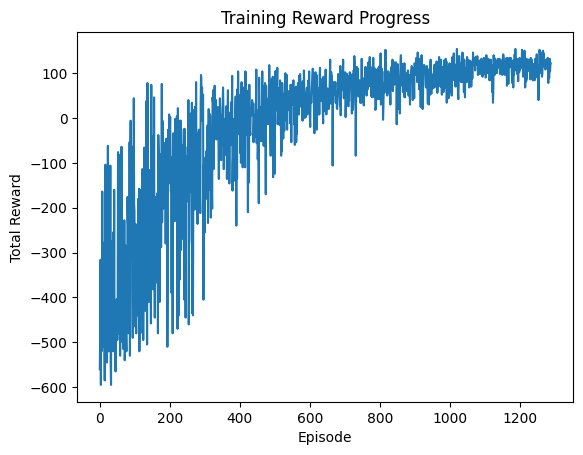

In [2]:
def train_robot():
    """
    This function trains the robot using Q-learning.

    The robot will:
    - Explore randomly at first
    - Slowly become smarter
    - Learn best actions for each state
    - Stop training early if no improvement
    """

    # Create environment (no rendering during training for speed)
    env = CleaningRobotEnv(render_mode=None)

    # ------------------------------------------------------------------
    # 1️⃣ Q-TABLE INITIALIZATION
    # ------------------------------------------------------------------
    # Q-table dimensions:
    # row (5) × col (5) × mask (16) × actions (4)
    #
    # Example:
    # Q[2,3,5,1] = value of taking action=RIGHT
    # when robot is at (2,3) and mask=5
    #
    q_table = np.zeros((5, 5, 16, 4))

    # ------------------------------------------------------------------
    # 2️⃣ HYPERPARAMETERS
    # ------------------------------------------------------------------

    episodes = 8000        # Maximum training episodes
    alpha = 0.1            # Learning rate (how fast we update knowledge)
    gamma = 0.95           # Discount factor (importance of future rewards)

    epsilon = 1.0          # Start fully random (100% exploration)
    min_epsilon = 0.05     # Minimum exploration
    decay = 0.0007         # How fast randomness decreases

    max_steps = 200        # Prevent infinite wandering

    # Store reward history
    rewards_history = []

    # Moving average over last 200 episodes
    moving_avg = deque(maxlen=200)

    # Early stopping variables
    best_avg = -np.inf
    patience = 20
    no_improve_counter = 0

    # Show rendering every N episodes
    render_every = 500

    # ------------------------------------------------------------------
    # 3️⃣ MAIN TRAINING LOOP
    # ------------------------------------------------------------------

    for episode in range(episodes):

        state, _ = env.reset()
        total_reward = 0
        done = False
        step_count = 0

        # Run until finished or max steps reached
        while not done and step_count < max_steps:

            r, c, mask = state

            # ----------------------------------------------------------
            # ACTION SELECTION (Epsilon-Greedy)
            # ----------------------------------------------------------
            # With probability epsilon → random move
            # Otherwise → choose best known action
            if random.uniform(0,1) < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(q_table[r,c,mask])

            # Take action in environment
            next_state, reward, done, _, _ = env.step(action)

            nr, nc, nmask = next_state

            # ----------------------------------------------------------
            # Q-LEARNING UPDATE (Bellman Equation)
            # ----------------------------------------------------------
            # Formula:
            #
            # Q_new = Q_old + alpha * (reward + gamma * max_future_Q - Q_old)
            #
            old_value = q_table[r,c,mask,action]
            next_max = np.max(q_table[nr,nc,nmask])

            q_table[r,c,mask,action] = (
                old_value + alpha * (reward + gamma * next_max - old_value)
            )

            # Move to next state
            state = next_state
            total_reward += reward
            step_count += 1

            # Occasionally show training visually
            if episode % render_every == 0:
                env.render(episode)

        # --------------------------------------------------------------
        # After Episode Ends
        # --------------------------------------------------------------

        # Reduce randomness gradually
        epsilon = max(min_epsilon, epsilon * np.exp(-decay))

        rewards_history.append(total_reward)
        moving_avg.append(total_reward)

        avg_reward = np.mean(moving_avg)

        print(
            f"Episode {episode} | "
            f"Reward: {total_reward:.2f} | "
            f"Avg: {avg_reward:.2f} | "
            f"Epsilon: {epsilon:.3f}"
        )

        # --------------------------------------------------------------
        # EARLY STOPPING CHECK
        # --------------------------------------------------------------
        # If average reward does not improve for 20 checks → stop
        if avg_reward > best_avg + 1e-3:
            best_avg = avg_reward
            no_improve_counter = 0
        else:
            no_improve_counter += 1

        if no_improve_counter >= patience:
            print("\n🛑 Early stopping: No improvement detected.")
            break

    env.close()

    # ------------------------------------------------------------------
    # 4️⃣ PLOT TRAINING PERFORMANCE
    # ------------------------------------------------------------------
    plt.plot(rewards_history)
    plt.title("Training Reward Progress")
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.show()

    return q_table


# ==============================================================================
# FINAL DEMO (RUN TRAINED POLICY)
# ==============================================================================

def demo(q_table):
    """
    Runs the trained robot with NO randomness.
    Always chooses best learned action.
    """

    env = CleaningRobotEnv(render_mode="human")

    state, _ = env.reset()
    done = False
    max_steps = 200
    step_count = 0

    while not done and step_count < max_steps:

        r, c, mask = state

        # Always choose best action
        action = np.argmax(q_table[r,c,mask])

        state, _, done, _, _ = env.step(action)

        # Render final learned behavior
        env.render("FINAL POLICY")

        step_count += 1

    time.sleep(3)
    env.close()


# ==============================================================================
# MAIN EXECUTION
# ==============================================================================

if __name__ == "__main__":

    # Train the robot
    q = train_robot()

    # Show final learned behavior
    demo(q)